# Imports

In [24]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Problem 1

## Part 1

Reading graph from Wikispeed

In [25]:
G = nx.read_edgelist("./Midterm_2026/wikispeedia.edgelist", create_using = nx.DiGraph)

Evaluating hits centrality

In [26]:
hubs, authorities = nx.hits(G)
hits = pd.DataFrame({'Hub' : hubs, 'Authority' : authorities})

In [79]:
print("Node with the highest hub value")
hits[hits['Hub'] == hits['Hub'].max()]

Node with the highest hub value


,Hub,Authority
Driving_on_the_left_or_right,0.002274,-0.0


In [28]:
print("Node with the highest authority value")
hits[hits['Authority'] == hits['Authority'].max()]

Node with the highest authority value


,Hub,Authority
United_States,0.001829,0.011525


## Part 2

Total number of nodes, N

In [29]:
N = G.number_of_nodes()

Creating initial state probability

In [30]:
pi0 = np.ones(N,) / N

Creating W matrix

In [31]:
def createW(G: nx.Graph, node_list, alpha: float = 0.1):

    N = G.number_of_nodes()
    W = np.zeros((N, N))

    out_degree = np.array([out for node,out in G.out_degree(node_list)])
    
    # If a node's neighborhood is empty, the entire row = 1/N
    W[out_degree == 0] = 1/N
    
    # For all rows with out_degree > 0 (non empty out neighborhoods)
    # base probability is set to alpha / N
    W[out_degree > 0] = alpha/N
    
    # The nodes actually in out-neightborhoods will recieve an additional probability boost
    A = nx.adjacency_matrix(G, node_list)
    W[out_degree > 0] += (A[out_degree > 0].T * (1 - alpha) / out_degree[out_degree > 0]).T
        
    return W


In [32]:
node_list = list(G.nodes())
alpha = 0.1
W = createW(G, node_list, alpha)

Iterating to find page rank

In [33]:
pi = pi0
pi_new = None
tol = 1E-10
max_iter = 200

for n in range(max_iter):
    pi_new = W.T @ pi
    
    if np.linalg.norm(pi_new - pi) <= tol:
        break
    
    pi = pi_new

In [34]:
calculated_pagerank = dict(zip(node_list, pi))
nx_pagerank = nx.pagerank(G, 1 - alpha)

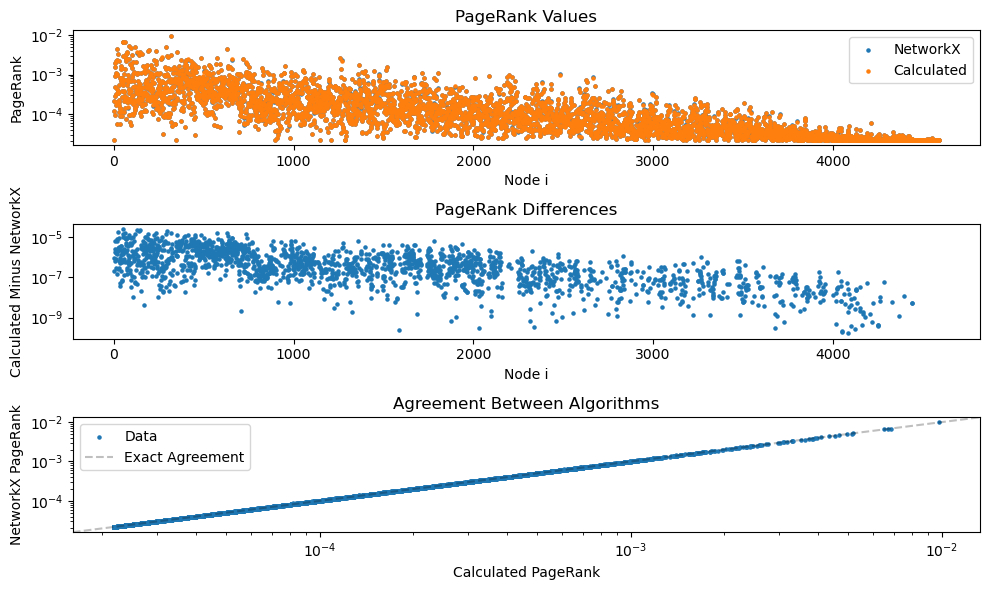

In [68]:
fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize = (10,6))
ax1.scatter([n for n in range(len(G.nodes()))], np.array(list(nx_pagerank.values())), s = 5, label = 'NetworkX')
ax1.scatter([n for n in range(len(G.nodes()))], np.array(list(calculated_pagerank.values())), s = 5, label = 'Calculated')

ax1.set_title('PageRank Values')
ax1.set_yscale('log')
ax1.set_xlabel('Node i')
ax1.set_ylabel('PageRank')
ax1.legend()

ax2.scatter([n for n in range(len(G.nodes()))], np.array(list(calculated_pagerank.values())) - np.array(list(nx_pagerank.values())), s = 5, label = 'Calculated')
ax2.set_ylabel('Calculated Minus NetworkX')
ax2.set_xlabel('Node i')
ax2.set_title('PageRank Differences')
ax2.set_yscale('log')

ax3.scatter(calculated_pagerank.values(), nx_pagerank.values(), s = 5, label = 'Data')
ax3.axline((0,0), slope = 1, color = 'black', linestyle = '--', alpha = 0.25, label = 'Exact Agreement')
ax3.set_xlabel('Calculated PageRank')
ax3.set_ylabel('NetworkX PageRank')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title('Agreement Between Algorithms')
ax3.legend()
plt.tight_layout()
plt.show()

# Problem 2

## Part 1

Creating **connected** Random Geometrix Graph

In [195]:
N = 100
radius = 0.25
G = nx.random_geometric_graph(N, radius)
if not nx.is_connected(G):
    while not nx.is_connected(G):
        G = nx.random_geometric_graph(N, radius)

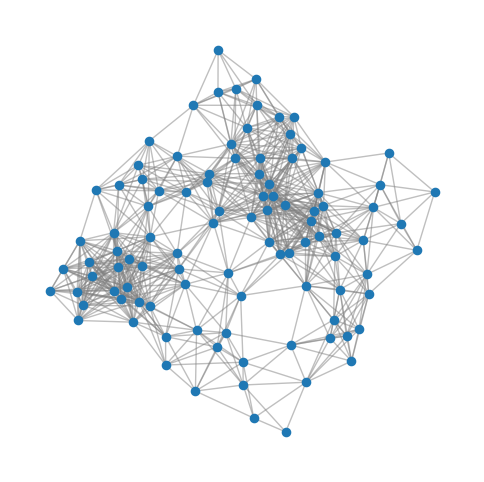

In [209]:
fig = plt.figure(figsize = (6,6))
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_nodes(G, pos, node_size = 35)
nx.draw_networkx_edges(G, pos, edge_color='grey', alpha = 0.5)
plt.axis('off')
plt.show()

## Part 2

In [210]:
p = 0.2
seed = 2026
rng = np.random.default_rng(seed = seed)

In [211]:
def next_state(x, edgelist, rng):
    
    x_new = x.copy()
    # randomly select element from list
    gossip_edge = edgelist[rng.integers(len(edgelist))]
    u, v = gossip_edge
    # Compute Average
    avg = 0.5 * (x[u] + x[v])
    x_new[[u, v]] = avg
    
    return x_new

In [ ]:
x = rng.binomial(1, p=p, size = N).astype(float)
T = 10000

# x0 and T next steps
x_hist = np.zeros((T+1, N))

# Adding first entry
x_hist[0] = x

# Iterating
for n in range(1, T + 1):
    
    x_hist[n] = next_state(x_hist[n-1], list(G.edges()), rng)

0.16


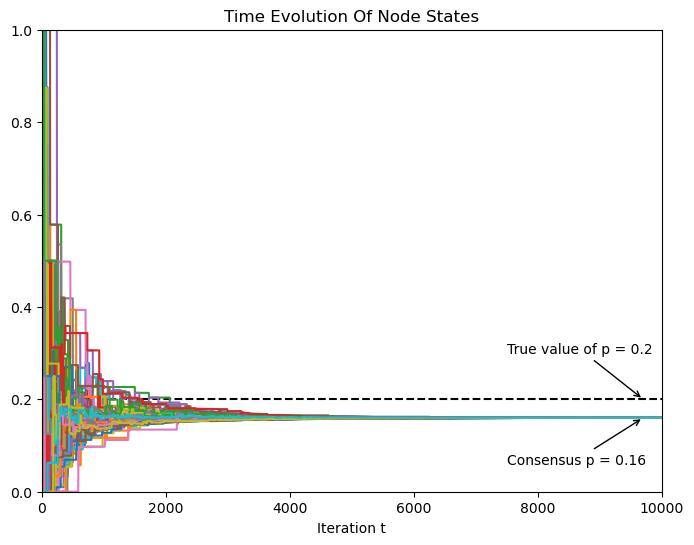

In [218]:
fig = plt.figure(figsize = (8, 6))
ax = plt.gca()

t = [n for n in range(T+1)]

plt.axhline(p, color=(0, 0, 0, 1), linestyle='--')


p_estimate = np.mean(x_hist[-1])

consensus = x_hist[-1, 0]
if x_hist[-1, 0] - 0.1 > 0 and x_hist[-1, 0] < p:
    xytext = (7500, p_estimate - 0.1)
    ptext = (7500, p + 0.1)

elif x_hist[-1, 0] > p:
    xytext = (7500, p_estimate + 0.1)
    ptext = (7500, p - 0.1)
    
elif p_estimate - 0.1 < 0 and p_estimate < p:
    xytext = (7500, p_estimate + 0.05)
    ptext = (7500, p + 0.1)
    
ax.annotate(f"True value of p = {p}", xytext=ptext, xy=(9700, p),
            arrowprops=dict(arrowstyle="->"))
ax.annotate(f"Consensus p = {p_estimate:2.2f}", xytext=xytext, xy=(9700, p_estimate),
            arrowprops=dict(arrowstyle="->"))

for node in range(N):
    plt.plot(t, x_hist[:, node])

plt.xlim((0, T))
plt.ylim((0, 1))

plt.title('Time Evolution of Node States'.title())
plt.xlabel('Iteration t')
plt.ylabel('')
plt.show()

## Part 3

\begin{gather*}
\mathbb{E}\left[ W \right] = I - \frac{1}{|\mathcal{E}|} L
\end{gather*}

## Part 4

In [214]:
Wbar = np.eye(N) - 1/len(G.edges()) * nx.laplacian_matrix(G).toarray()
lambda2 = np.linalg.eigvalsh(Wbar)[::-1][1]
print(f"lambda_2(Wbar) = {lambda2:0.6f}")

lambda_2(Wbar) = 0.998948
